In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotting style set karo — professional look
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# Cleaned dataset load karo
df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/data_cleaning.ipynb')

# Date column → datetime (CSV se load karne pe phir string banta hai)
df['Date']       = pd.to_datetime(df['Date'])
df['Month']      = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Year']       = df['Date'].dt.year
df['Quarter']    = df['Date'].dt.quarter
df['Day_Name']   = df['Date'].dt.strftime('%A')

print(f"✅ Dataset loaded: {df.shape}")
print(f"💰 Total Revenue : ₹{df['Amount'].sum():,.2f}")

✅ Dataset loaded: (128975, 28)
💰 Total Revenue : ₹78,592,678.30


       AMAZON SALES — KEY METRICS
  💰 Total Revenue    : ₹78,592,678.30
  📦 Total Orders     :      120,378
  🧾 Avg Order Value  : ₹      609.36
  📦 Total Units Sold :      116,649
  ❌ Cancellation Rate:       14.21%


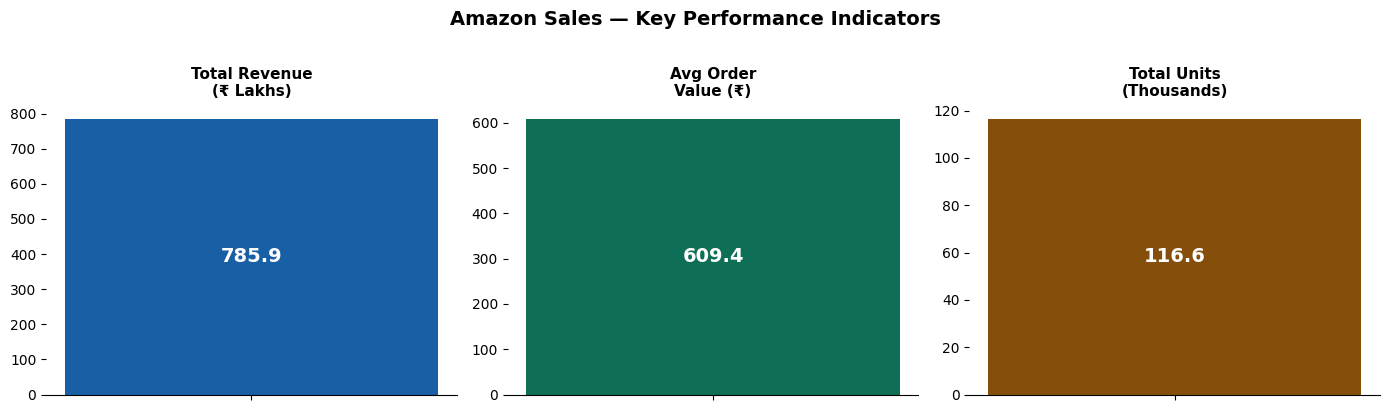

In [2]:
# ── SALES OVERVIEW ──────────────────────────
total_revenue   = df['Amount'].sum()
total_orders    = df['Order ID'].nunique()
avg_order_value = df['Amount'].mean()
total_units     = df['Qty'].sum()
cancelled_pct   = (df['Status'].value_counts(normalize=True).get('Cancelled',0)*100)

print("=" * 45)
print("       AMAZON SALES — KEY METRICS")
print("=" * 45)
print(f"  💰 Total Revenue    : ₹{total_revenue:>12,.2f}")
print(f"  📦 Total Orders     : {total_orders:>12,}")
print(f"  🧾 Avg Order Value  : ₹{avg_order_value:>12,.2f}")
print(f"  📦 Total Units Sold : {total_units:>12,}")
print(f"  ❌ Cancellation Rate: {cancelled_pct:>11.2f}%")
print("=" * 45)

# Visual — KPI bar chart
metrics = ['Total Revenue(L)', 'Avg Order Val', 'Total Units']
values  = [total_revenue/100000, avg_order_value, total_units/1000]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#185FA5','#0F6E56','#854F0B']
labels = ['Total Revenue\n(₹ Lakhs)', 'Avg Order\nValue (₹)', 'Total Units\n(Thousands)']

for i,(ax,val,col,lbl) in enumerate(zip(axes,values,colors,labels)):
    ax.bar([''], [val], color=col, width=0.4)
    ax.set_title(lbl, fontsize=11, fontweight='bold')
    ax.set_ylabel('')
    ax.text(0, val*0.5, f'{val:,.1f}', ha='center',
            va='center', fontsize=14, fontweight='bold', color='white')
    ax.spines[['top','right','left']].set_visible(False)

plt.suptitle('Amazon Sales — Key Performance Indicators',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

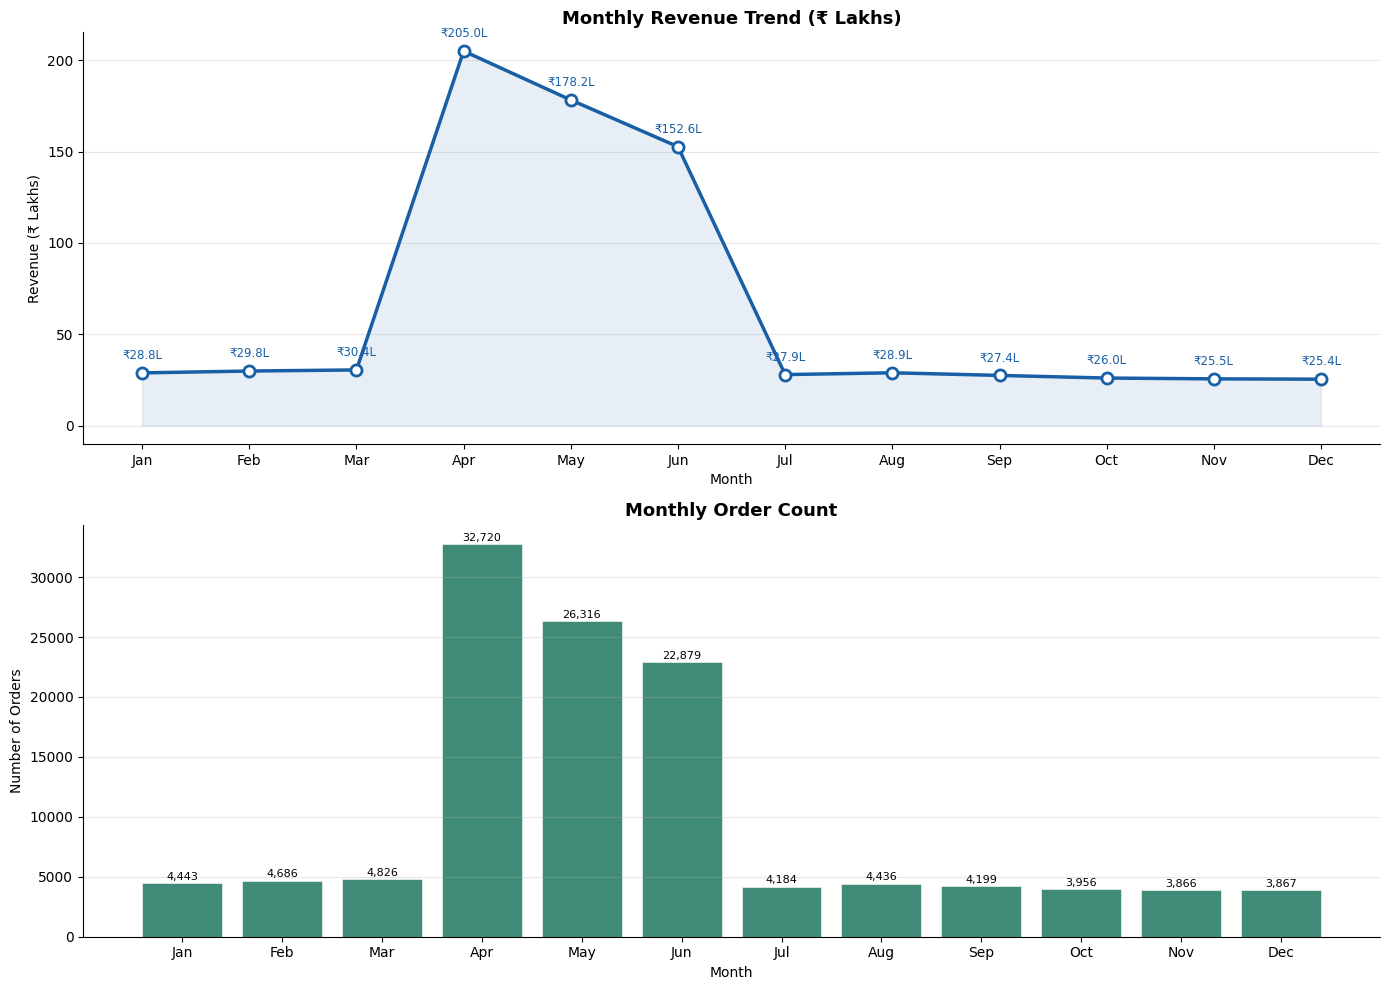

📈 Peak Month: April — ₹20,500,095


In [3]:
# ── MONTHLY SALES TREND ─────────────────────
monthly = df.groupby(['Year','Month','Month_Name'])['Amount'].sum().reset_index()
monthly = monthly.sort_values(['Year','Month'])
monthly['Month_Short'] = pd.to_datetime(monthly['Month'], format='%m').dt.strftime('%b')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Chart 1 — Revenue line
ax1 = axes[0]
ax1.plot(monthly['Month_Short'], monthly['Amount']/100000,
         color='#185FA5', linewidth=2.5, marker='o',
         markersize=8, markerfacecolor='white', markeredgewidth=2)
ax1.fill_between(range(len(monthly)), monthly['Amount']/100000,
                 alpha=0.1, color='#185FA5')

for i, row in monthly.iterrows():
    ax1.annotate(f"₹{row['Amount']/100000:.1f}L",
                xy=(list(monthly['Month_Short']).index(row['Month_Short']),
                    row['Amount']/100000),
                xytext=(0,10), textcoords='offset points',
                ha='center', fontsize=8.5, color='#185FA5')

ax1.set_title('Monthly Revenue Trend (₹ Lakhs)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (₹ Lakhs)')
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# Chart 2 — Monthly order count
monthly_orders = df.groupby(['Month','Month_Name'])['Order ID'].nunique().reset_index()
monthly_orders = monthly_orders.sort_values('Month')
monthly_orders['Month_Short'] = pd.to_datetime(monthly_orders['Month'],format='%m').dt.strftime('%b')

ax2 = axes[1]
bars = ax2.bar(monthly_orders['Month_Short'], monthly_orders['Order ID'],
               color='#0F6E56', alpha=0.8, edgecolor='white', linewidth=0.5)
ax2.set_title('Monthly Order Count', fontsize=13, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Orders')
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

for bar in bars:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Peak month find karo
peak = monthly.loc[monthly['Amount'].idxmax()]
print(f"📈 Peak Month: {peak['Month_Name']} — ₹{peak['Amount']:,.0f}")

Category Performance:
     Category     Revenue  Orders  Avg_Value  Units
          Set 39204124.03   47845 779.654046  45289
        Kurta 21299546.70   46561 427.041456  45045
Western Dress 11216072.69   14994 723.617593  13943
          Top  5347792.30   10155 503.463783   9903
 Ethnic Dress   791217.66    1148 682.672701   1053
       Blouse   458408.18     897 495.041231    863
       Bottom   150667.98     410 342.427227    398
        Saree   123933.76     144 755.693659    152
      Dupatta      915.00       2 305.000000      3


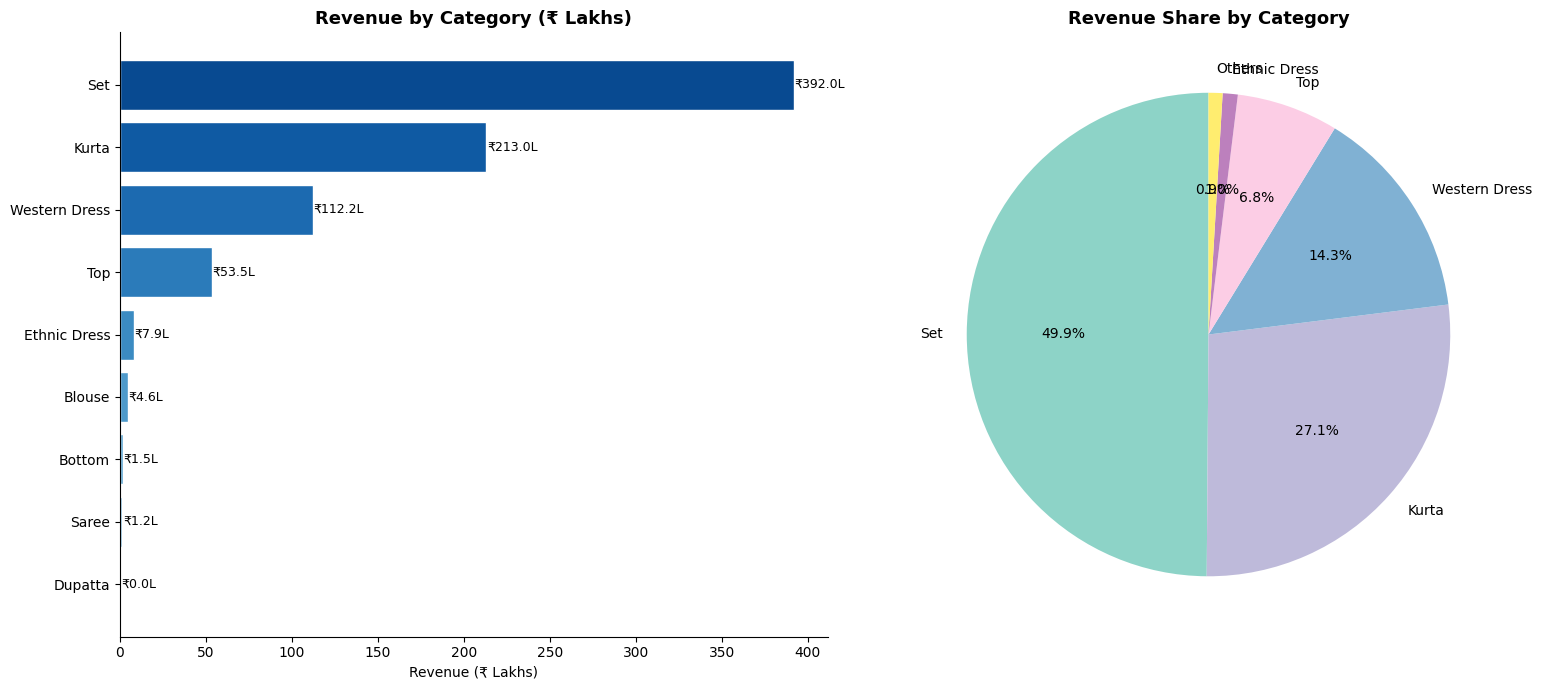

In [4]:
# ── CATEGORY ANALYSIS ───────────────────────
cat_revenue = df.groupby('Category').agg(
    Revenue     = ('Amount','sum'),
    Orders      = ('Order ID','nunique'),
    Avg_Value   = ('Amount','mean'),
    Units       = ('Qty','sum')
).reset_index().sort_values('Revenue', ascending=False)

print("Category Performance:")
print(cat_revenue.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1 — Revenue by category
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(cat_revenue)))[::-1]
bars = axes[0].barh(cat_revenue['Category'],
                    cat_revenue['Revenue']/100000,
                    color=colors_bar, edgecolor='white')

axes[0].set_title('Revenue by Category (₹ Lakhs)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue (₹ Lakhs)')
axes[0].invert_yaxis()
axes[0].spines[['top','right']].set_visible(False)

for bar, val in zip(bars, cat_revenue['Revenue']/100000):
    axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                 f'₹{val:.1f}L', va='center', fontsize=9)

# Chart 2 — Pie chart for share
top5 = cat_revenue.head(5)
others = cat_revenue.tail(len(cat_revenue)-5)['Revenue'].sum()
pie_data  = list(top5['Revenue']) + [others]
pie_labels= list(top5['Category']) + ['Others']

axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
            startangle=90,
            colors=plt.cm.Set3(np.linspace(0,1,len(pie_data))))
axes[1].set_title('Revenue Share by Category',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

Top 10 States by Revenue:
    ship-state     Revenue  Orders
   Maharashtra 13335534.14   20780
     Karnataka 10481114.37   16182
     Telangana  6916615.65   10405
 Uttar Pradesh  6816642.08   10062
    Tamil Nadu  6515650.11   10519
         Delhi  4346412.46    6533
        Kerala  3830227.58    6105
   West Bengal  3507880.44    5653
Andhra Pradesh  3219831.72    4979
       Haryana  2882092.99    4142


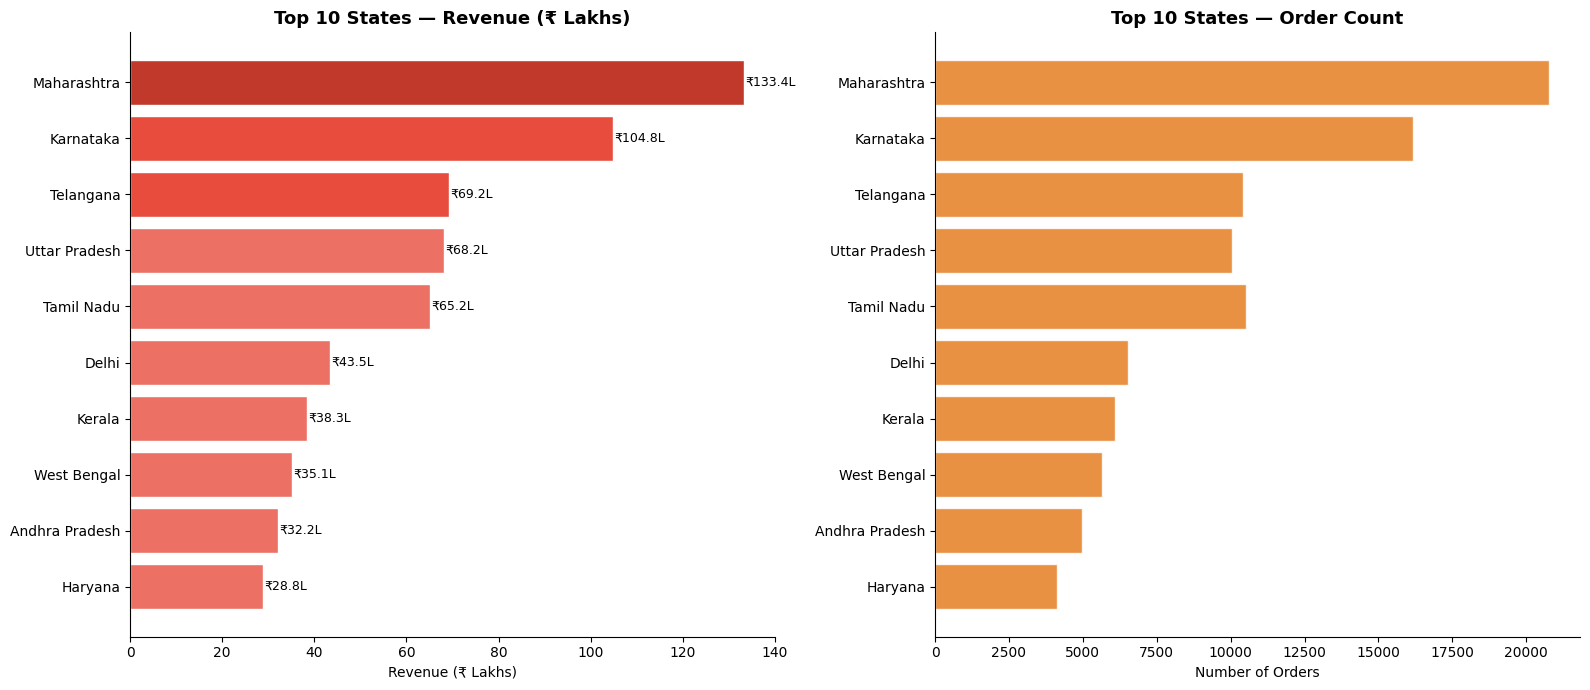

In [5]:
# ── STATE-WISE ANALYSIS ─────────────────────
state_data = df.groupby('ship-state').agg(
    Revenue = ('Amount','sum'),
    Orders  = ('Order ID','nunique'),
    Avg_Val = ('Amount','mean')
).reset_index().sort_values('Revenue', ascending=False)

top10_states = state_data.head(10)
print("Top 10 States by Revenue:")
print(top10_states[['ship-state','Revenue','Orders']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1 — Top 10 states revenue
colors_s = ['#C0392B' if i==0 else '#E74C3C' if i<3 else '#EC7063'
            for i in range(len(top10_states))]
bars = axes[0].barh(top10_states['ship-state'],
                    top10_states['Revenue']/100000,
                    color=colors_s, edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 States — Revenue (₹ Lakhs)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue (₹ Lakhs)')
axes[0].spines[['top','right']].set_visible(False)

for bar, val in zip(bars, top10_states['Revenue']/100000):
    axes[0].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f'₹{val:.1f}L', va='center', fontsize=9)

# Chart 2 — Top 10 states orders
axes[1].barh(top10_states['ship-state'],
             top10_states['Orders'],
             color='#E67E22', alpha=0.85, edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 States — Order Count',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Orders')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

Order Status Distribution:
                       Status  Count  Percentage
                      Shipped  77804       60.32
 Shipped - Delivered To Buyer  28769       22.31
                    Cancelled  18332       14.21
 Shipped - Returned To Seller   1953        1.51
          Shipped - Picked Up    973        0.75
                      Pending    658        0.51
Pending - Waiting For Pick Up    281        0.22
Shipped - Returning To Seller    145        0.11
   Shipped - Out For Delivery     35        0.03
  Shipped - Rejected By Buyer     11        0.01
                     Shipping      8        0.01
    Shipped - Lost In Transit      5        0.00
            Shipped - Damaged      1        0.00

Fulfilment Type Performance:
Fulfilment  Orders    Revenue    Avg_Val
    Amazon   84002 54322151.0 605.611619
  Merchant   36376 24270527.3 617.932309


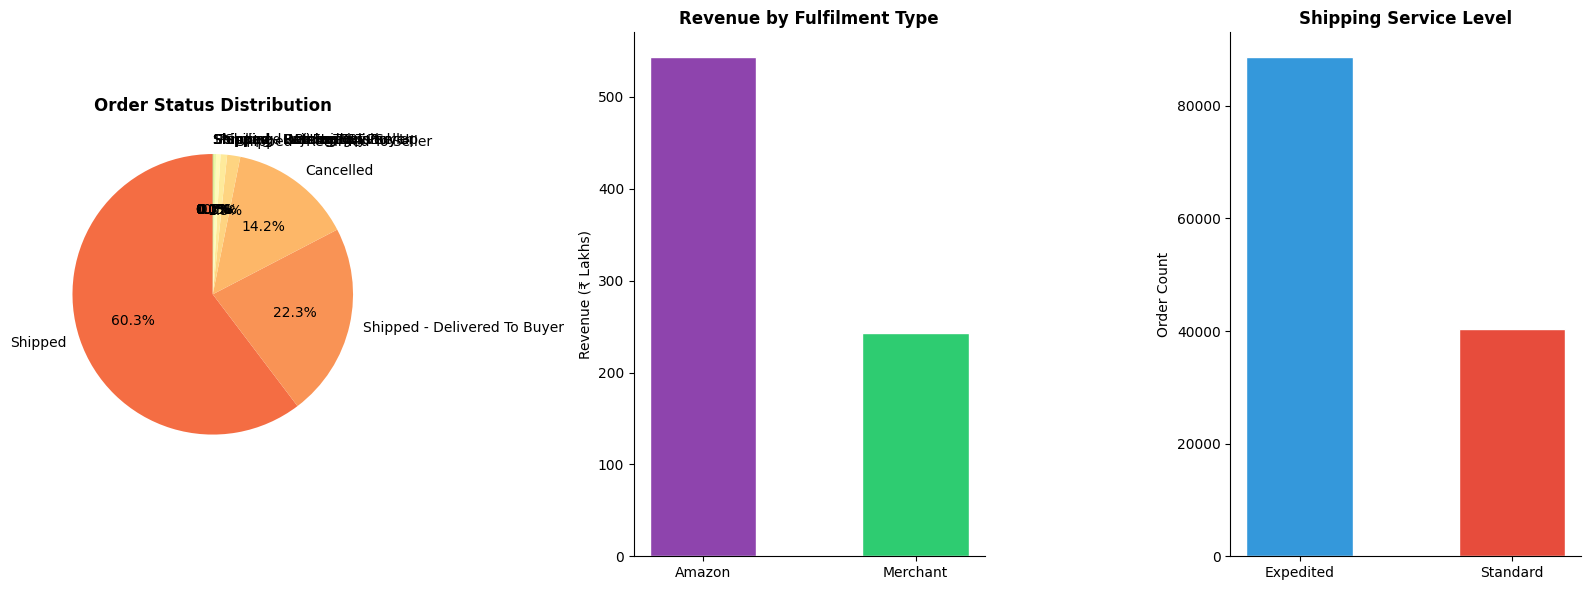

In [6]:
# ── FULFILLMENT ANALYSIS ────────────────────
# Status distribution
status_counts = df['Status'].value_counts().reset_index()
status_counts.columns = ['Status','Count']
status_counts['Percentage'] = (status_counts['Count']/len(df)*100).round(2)
print("Order Status Distribution:")
print(status_counts.to_string(index=False))

# Fulfilment type analysis
ful_data = df.groupby('Fulfilment').agg(
    Orders  = ('Order ID','nunique'),
    Revenue = ('Amount','sum'),
    Avg_Val = ('Amount','mean')
).reset_index()
print("\nFulfilment Type Performance:")
print(ful_data.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Chart 1 — Order Status pie
axes[0].pie(status_counts['Count'],
            labels=status_counts['Status'],
            autopct='%1.1f%%', startangle=90,
            colors=plt.cm.RdYlGn(np.linspace(0.2,0.9,len(status_counts))))
axes[0].set_title('Order Status Distribution',fontsize=12,fontweight='bold')

# Chart 2 — Fulfilment revenue
axes[1].bar(ful_data['Fulfilment'], ful_data['Revenue']/100000,
            color=['#8E44AD','#2ECC71'], edgecolor='white', width=0.5)
axes[1].set_title('Revenue by Fulfilment Type',fontsize=12,fontweight='bold')
axes[1].set_ylabel('Revenue (₹ Lakhs)')
axes[1].spines[['top','right']].set_visible(False)

# Chart 3 — Shipping service level
ship_data = df['ship-service-level'].value_counts()
axes[2].bar(ship_data.index, ship_data.values,
            color=['#3498DB','#E74C3C'], edgecolor='white', width=0.5)
axes[2].set_title('Shipping Service Level',fontsize=12,fontweight='bold')
axes[2].set_ylabel('Order Count')
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

B2B vs B2C:
Type  Orders     Revenue    Avg_Val
 B2C  119584 78001457.51 608.891662
 B2B     794   591220.79 678.783915


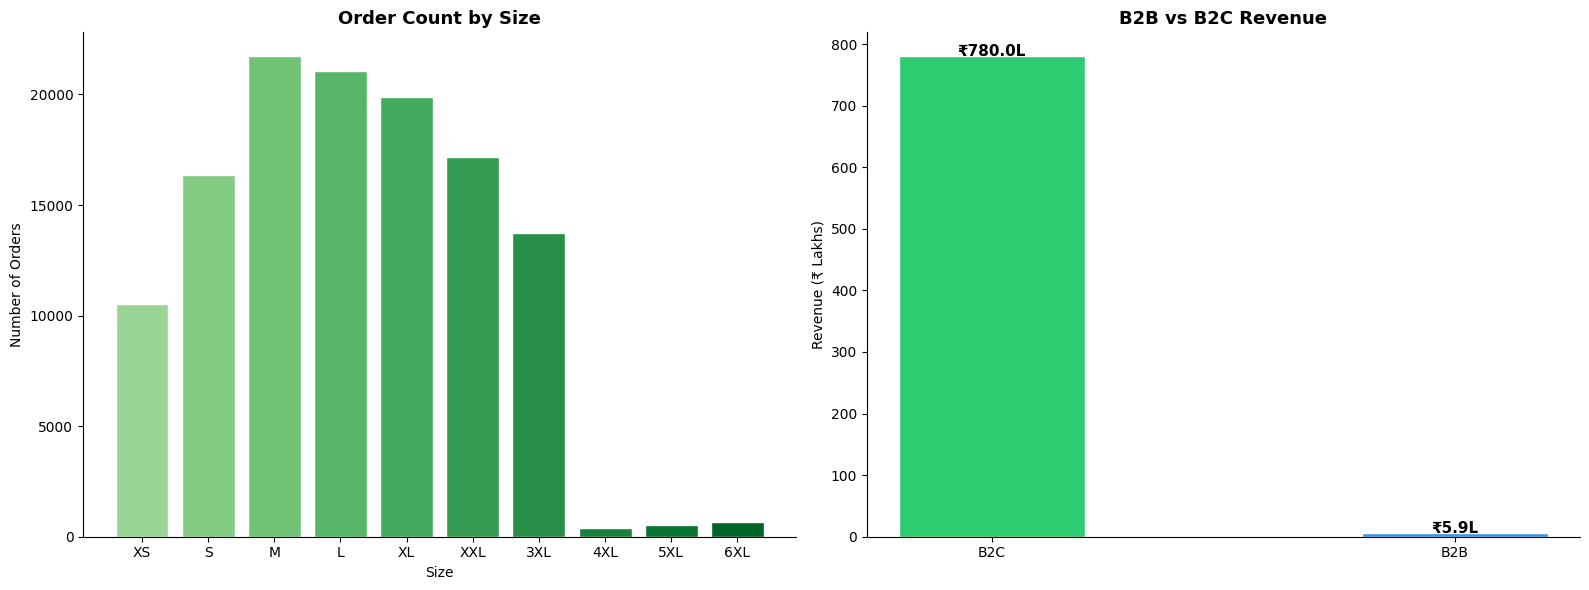

In [7]:
# ── SIZE & B2B ANALYSIS ─────────────────────
# Size distribution
size_order = ['XS','S','M','L','XL','XXL','3XL','4XL','5XL','6XL','Free']
size_data = df.groupby('Size').agg(
    Orders  = ('Order ID','nunique'),
    Revenue = ('Amount','sum')
).reset_index()

# Existing sizes filter
size_data = size_data[size_data['Size'].isin(size_order)]
size_data['Size'] = pd.Categorical(size_data['Size'],
                                    categories=size_order, ordered=True)
size_data = size_data.sort_values('Size')

# B2B analysis
b2b_data = df.groupby('B2B').agg(
    Orders  = ('Order ID','nunique'),
    Revenue = ('Amount','sum'),
    Avg_Val = ('Amount','mean')
).reset_index()
b2b_data['Type'] = b2b_data['B2B'].map({True:'B2B',False:'B2C'})
print("B2B vs B2C:")
print(b2b_data[['Type','Orders','Revenue','Avg_Val']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Size popularity
axes[0].bar(size_data['Size'], size_data['Orders'],
            color=plt.cm.Greens(np.linspace(0.4,0.9,len(size_data))),
            edgecolor='white')
axes[0].set_title('Order Count by Size',fontsize=13,fontweight='bold')
axes[0].set_xlabel('Size')
axes[0].set_ylabel('Number of Orders')
axes[0].spines[['top','right']].set_visible(False)

# Chart 2 — B2B vs B2C
x = np.arange(2)
axes[1].bar(b2b_data['Type'], b2b_data['Revenue']/100000,
            color=['#2ECC71','#3498DB'], width=0.4, edgecolor='white')
axes[1].set_title('B2B vs B2C Revenue',fontsize=13,fontweight='bold')
axes[1].set_ylabel('Revenue (₹ Lakhs)')
axes[1].spines[['top','right']].set_visible(False)

for i,(val,typ) in enumerate(zip(b2b_data['Revenue']/100000, b2b_data['Type'])):
    axes[1].text(i, val+0.5, f'₹{val:.1f}L', ha='center',fontsize=11,fontweight='bold')

plt.tight_layout()
plt.show()

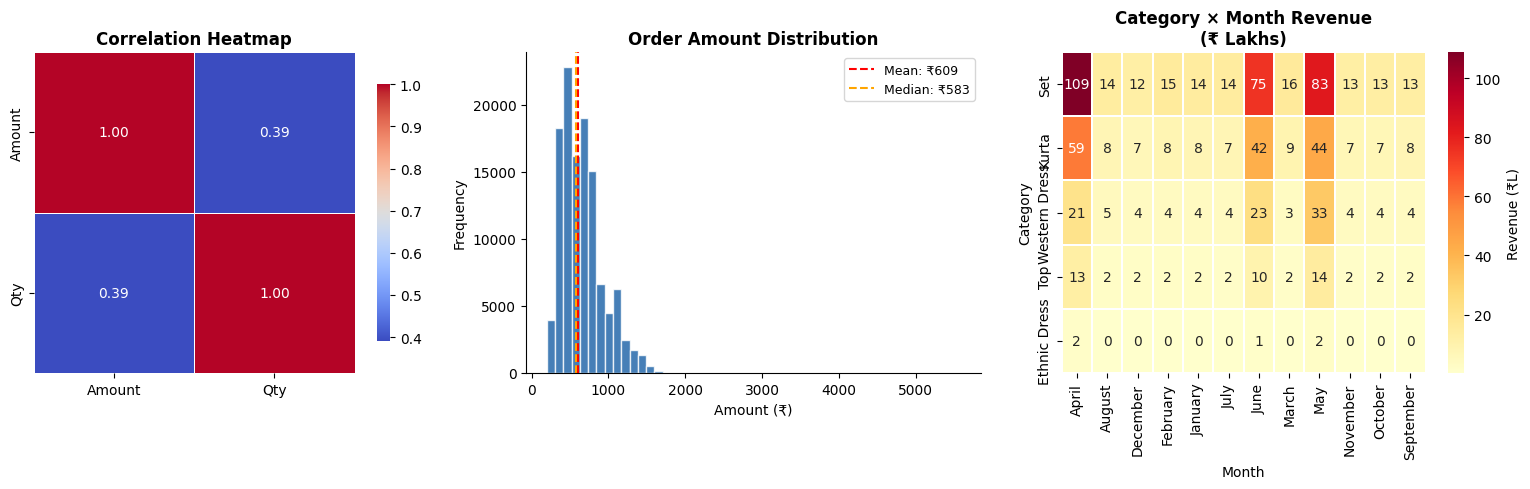


Correlation between Amount & Qty: 0.391
Interpretation: Closer to 1 = strong positive relation


In [8]:
# ── CORRELATION & DISTRIBUTION ──────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1 — Correlation heatmap
num_cols = df[['Amount','Qty']].copy()
corr = num_cols.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], square=True, linewidths=0.5,
            cbar_kws={'shrink':0.8})
axes[0].set_title('Correlation Heatmap',fontsize=12,fontweight='bold')

# Chart 2 — Amount distribution
axes[1].hist(df[df['Amount']>0]['Amount'], bins=50,
             color='#185FA5', edgecolor='white', alpha=0.8)
axes[1].set_title('Order Amount Distribution',fontsize=12,fontweight='bold')
axes[1].set_xlabel('Amount (₹)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['Amount'].mean(), color='red',
                linestyle='--', label=f"Mean: ₹{df['Amount'].mean():.0f}")
axes[1].axvline(df['Amount'].median(), color='orange',
                linestyle='--', label=f"Median: ₹{df['Amount'].median():.0f}")
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

# Chart 3 — Top 10 categories heatmap (category x month)
cat_month = df.groupby(['Category','Month_Name'])['Amount'].sum().unstack(fill_value=0)

# Top 5 categories only
top5_cats = df.groupby('Category')['Amount'].sum().nlargest(5).index
cat_month_top = cat_month.loc[top5_cats]

sns.heatmap(cat_month_top/100000, annot=True, fmt='.0f',
            cmap='YlOrRd', ax=axes[2], linewidths=0.3,
            cbar_kws={'label':'Revenue (₹L)'})
axes[2].set_title('Category × Month Revenue\n(₹ Lakhs)',fontsize=12,fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Category')

plt.tight_layout()
plt.show()

print(f"\nCorrelation between Amount & Qty: {df['Amount'].corr(df['Qty']):.3f}")
print("Interpretation: Closer to 1 = strong positive relation")

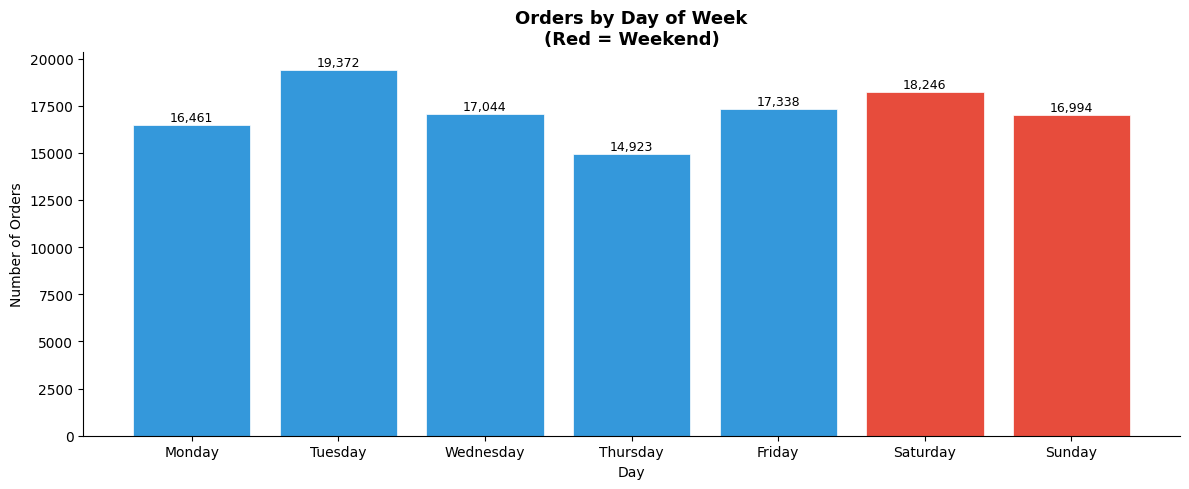

In [9]:
# Konse din sabse zyada orders aate hain?
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

day_data = df.groupby('Day_Name').agg(
    Orders  = ('Order ID','nunique'),
    Revenue = ('Amount','sum')
).reindex(day_order).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#E74C3C' if d in ['Saturday','Sunday']
          else '#3498DB' for d in day_data['Day_Name']]
bars = ax.bar(day_data['Day_Name'], day_data['Orders'],
              color=colors, edgecolor='white', linewidth=0.5)

ax.set_title('Orders by Day of Week\n(Red = Weekend)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Number of Orders')
ax.spines[['top','right']].set_visible(False)

for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+50,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Quarterly Revenue'}, xlabel='Quarter'>

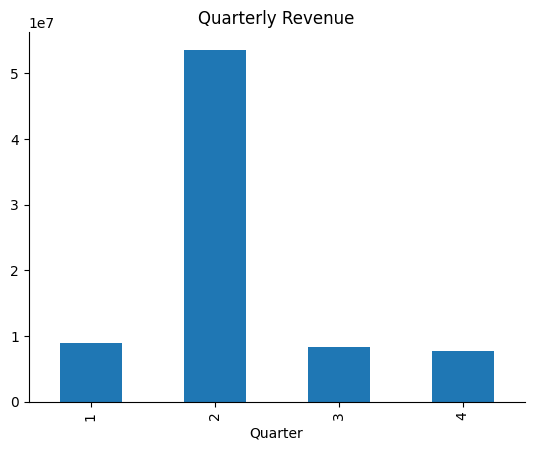

In [10]:
df.groupby('Quarter')['Amount'].sum().plot(
    kind='bar', title='Quarterly Revenue'
)